In [1]:
from fenics import *
import matplotlib.pyplot as plt

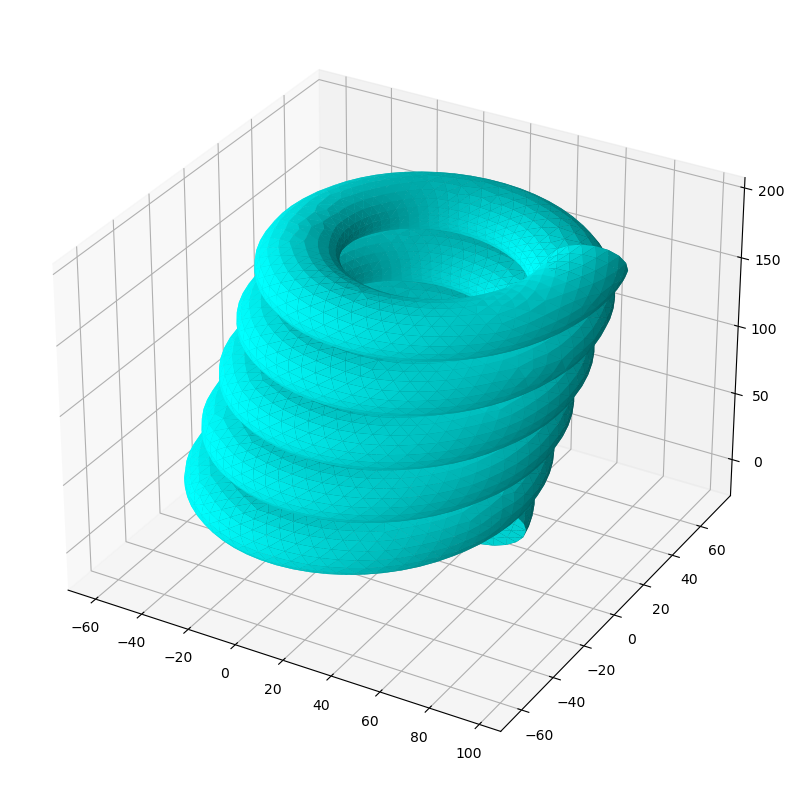

In [2]:
plt.figure(figsize=(10,10))
mesh = Mesh("helice.xml")
plot(mesh, color='cyan')

In [8]:
deltat = 0.1 
total_time = 25.0
k = 350 # coeficiente de difusividad térmica

In [9]:
#  espacio funcional
V = FunctionSpace(mesh, "P", 1)

In [10]:
# Leer el archivo para las superficies
caras = MeshFunction('size_t', mesh, "helice_facet_region.xml")

In [12]:
# condiciones de borde
u_entrada = 80
u_salida = -80

bc1 = DirichletBC(V, Constant(u_entrada), caras, 14)
bc2 = DirichletBC(V, Constant(u_salida), caras, 15)
bc = [bc1, bc2]

In [13]:
#  formulación variacional
u = TrialFunction(V)
v = TestFunction(V)
un = Function(V)

Helice = u*v*dx +  deltat*k*dot(grad(u), grad(v))*dx  - un*v*dx

a = lhs(Helice)
l = rhs(Helice)

In [14]:
vtkfile = File('solucion_2025I_402/helice.pvd')
u = Function(V)
t = 0

num_iter = int(total_time/deltat)
for n in range(num_iter):
    solve(a == l, u, bc)
    un.assign(u)
    vtkfile << (u, t)
    t += deltat

Calling FFC just-in-time (JIT) compiler, this may take some time.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem.
Solving linear variational problem